## Work with YOLO model

In [ ]:
import fiftyone as fo
import fiftyone.zoo as foz
from fiftyone import ViewField as F

from ultralytics import YOLO

import numpy as np
import os
from tqdm import tqdm

### run inference (quickstart)

Dataset already downloaded
Loading existing dataset 'quickstart'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


100%|██████████| 6.25M/6.25M [00:00<00:00, 11.6MB/s]


 100% |█████████████████| 200/200 [13.2s elapsed, 0s remaining, 15.6 samples/s]      



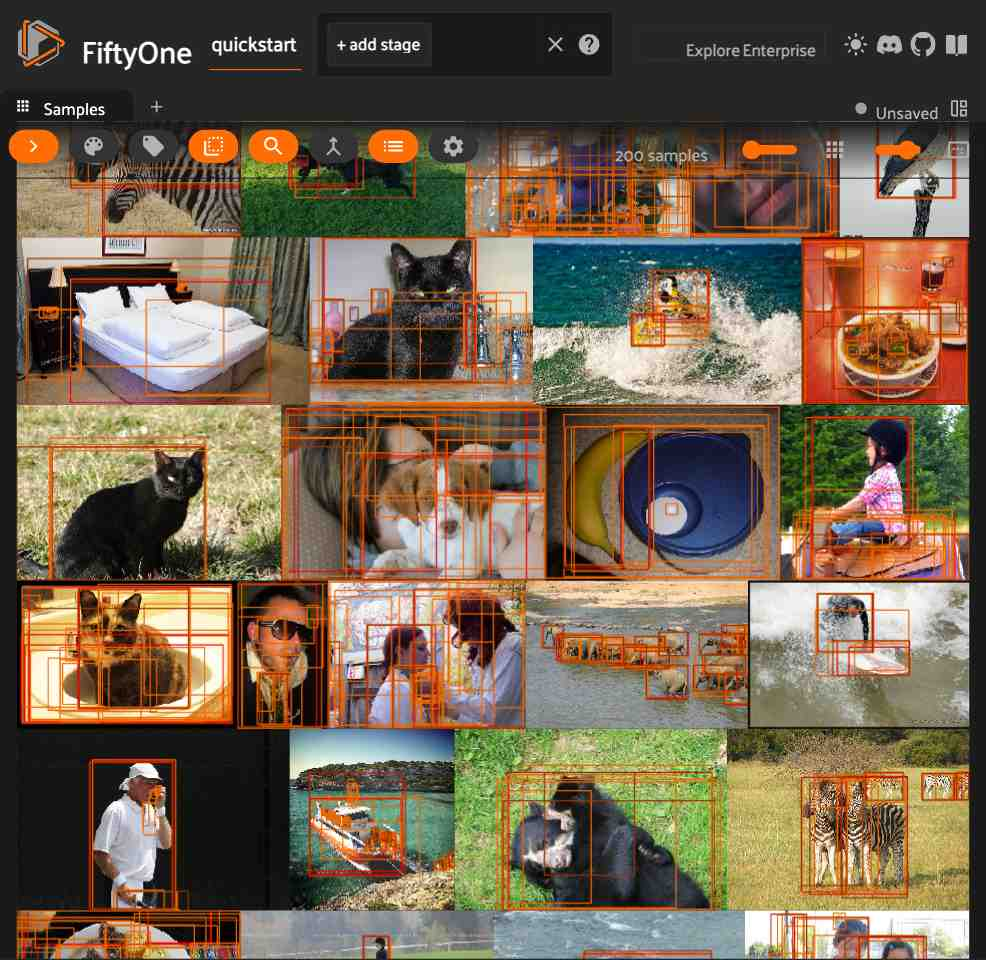

In [ ]:
dataset = foz.load_zoo_dataset("quickstart")
model = YOLO("yolov8n.pt")

dataset.apply_model(model, label_field="yolov8n")

session = fo.launch_app(dataset)

In [ ]:
fo.list_datasets()

['2025.06.19.17.22.46',
 '2025.06.19.17.57.43',
 'coco-2017-test',
 'demo0424',
 'evaluate-detections-tutorial',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'mnist-test',
 'quickstart',
 'quickstart-geo',
 'quickstart-video',
 'test_raw_imgs']

### run inference (coco2017-valid)

In [ ]:
dataset = foz.load_zoo_dataset("coco-2017", split="validation")

Found annotations at '/Users/bhc/fiftyone/coco-2017/raw/instances_val2017.json'
Images already downloaded
Existing download of split 'validation' is sufficient
Loading 'coco-2017' split 'validation'
 100% |███████████████| 5000/5000 [10.2s elapsed, 0s remaining, 519.3 samples/s]      
Dataset 'coco-2017-validation' created


In [ ]:
model = YOLO("yolov8n.pt")
dataset.apply_model(model, label_field="yolov8n")

 100% |███████████████| 5000/5000 [4.9m elapsed, 0s remaining, 18.8 samples/s]      



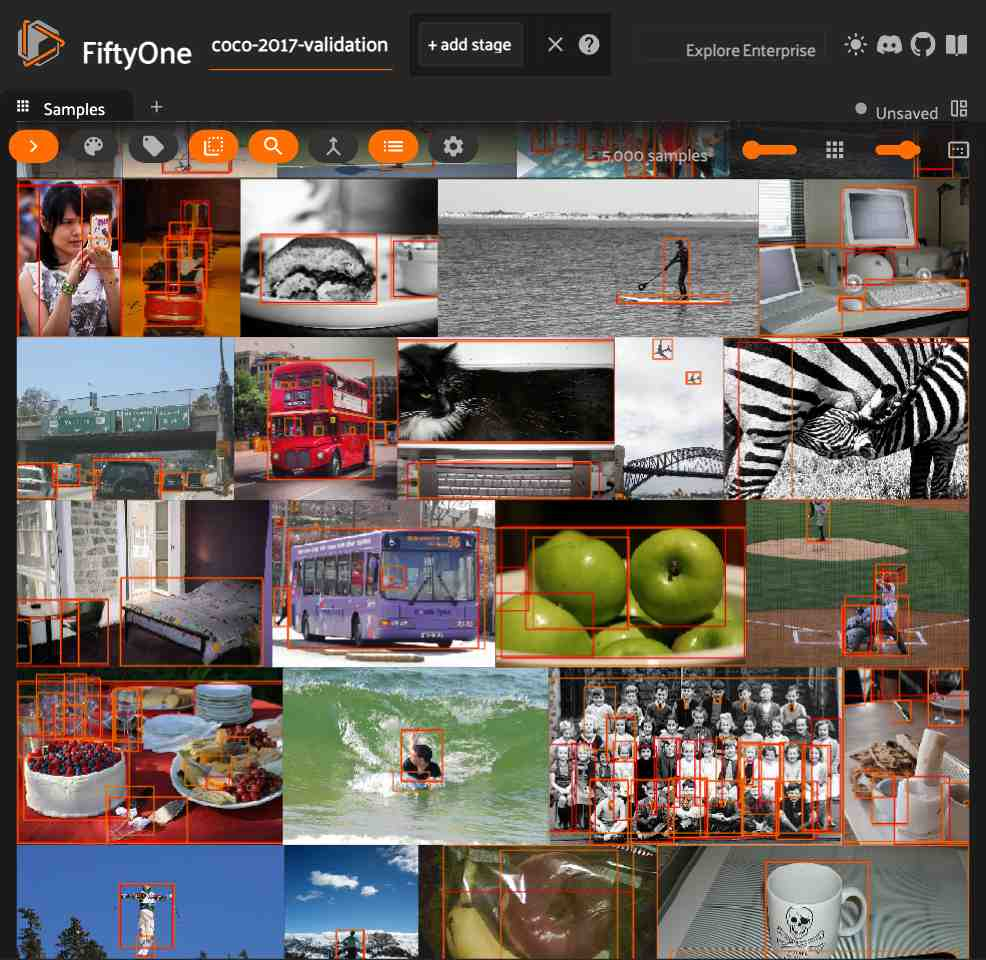

In [ ]:
session = fo.launch_app(dataset)

### data curations

test sets

In [ ]:
test_dataset = dataset.filter_labels(
    "ground_truth",
    F("label") == "bird"
).filter_labels(
    "yolov8n",
    F("label") == "bird",
    only_matches=False
).clone()

test_dataset.name = "birds-test-dataset"
test_dataset.persistent = True


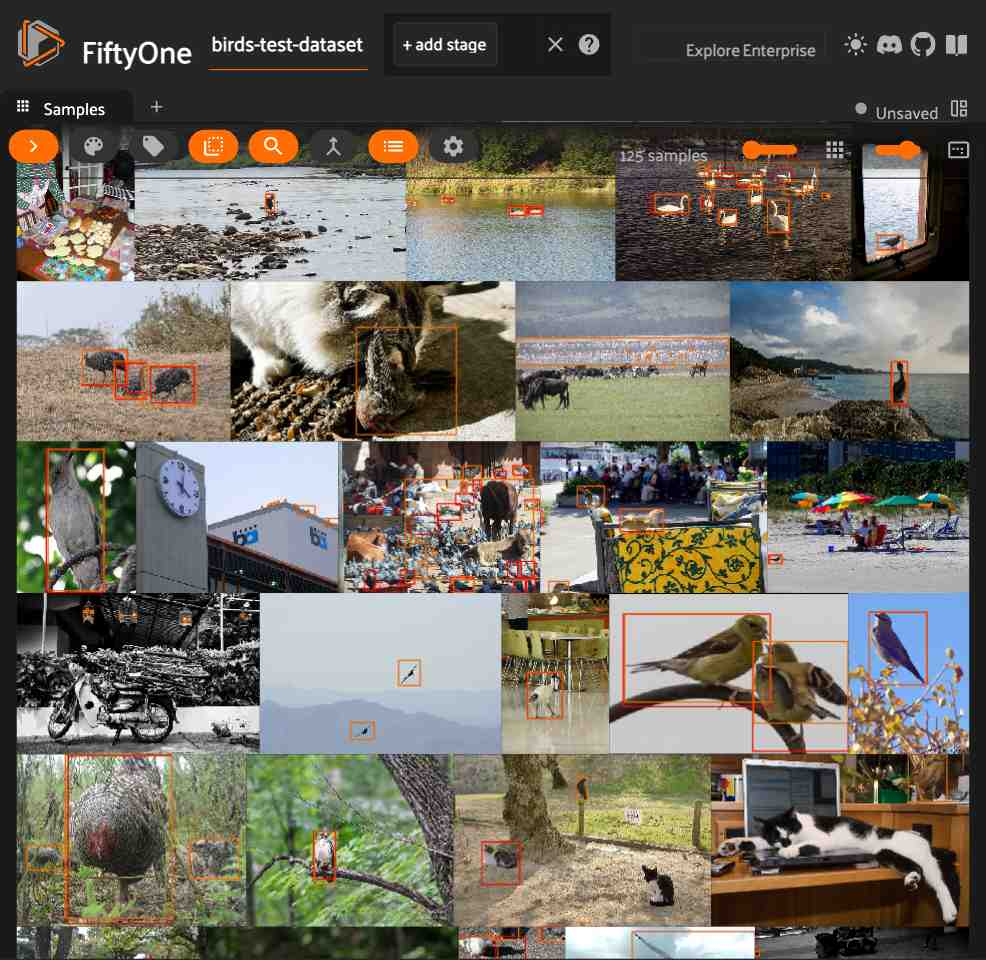

In [ ]:
session = fo.launch_app(test_dataset)

train sets (augmentation)

In [ ]:
## set classes to just include birds
classes = ["bird"]

In [ ]:
train_dataset = foz.load_zoo_dataset(
    'coco-2017',
    split='train',
    classes=classes
).clone()

train_dataset.name = "birds-train-data"
train_dataset.persistent = True
train_dataset.save()

Found annotations at '/Users/bhc/fiftyone/coco-2017/raw/instances_train2017.json'
 100% |████████████████| 3237/3237 [6.0m elapsed, 0s remaining, 8.9 images/s]       
Writing annotations for 3237 downloaded samples to '/Users/bhc/fiftyone/coco-2017/train/labels.json'
Dataset info written to '/Users/bhc/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'train'
 100% |███████████████| 3237/3237 [6.0s elapsed, 0s remaining, 553.9 samples/s]      
Dataset 'coco-2017-train' created


In [ ]:
oi_samples = foz.load_zoo_dataset(
    "open-images-v6",
    classes = ["Bird"],
    only_matching=True,
    label_types="detections"
).map_labels(
    "ground_truth",
    {"Bird":"bird"}
)

 100% |██████|    4.8Gb/4.8Gb [26.5s elapsed, 0s remaining, 176.8Mb/s]      
 100% |███████████████| 18525/18525 [16.9m elapsed, 0s remaining, 11.3 files/s]      
 100% |█████████████████| 1871/1871 [1.6m elapsed, 0s remaining, 20.7 files/s]      
 100% |███████████████████| 593/593 [39.0s elapsed, 0s remaining, 19.7 files/s]      
Dataset info written to '/Users/bhc/fiftyone/open-images-v6/info.json'
Loading 'open-images-v6' split 'train'
 100% |█████████████| 18525/18525 [21.9s elapsed, 0s remaining, 900.2 samples/s]      
Loading 'open-images-v6' split 'test'
 100% |███████████████| 1871/1871 [1.5s elapsed, 0s remaining, 1.2K samples/s]         
Loading 'open-images-v6' split 'validation'
 100% |█████████████████| 593/593 [420.9ms elapsed, 0s remaining, 1.4K samples/s]      
Dataset 'open-images-v6' created


In [ ]:
train_dataset.merge_samples(oi_samples)

In [ ]:
session = fo.launch_app(train_dataset)

### fine-tuning YOLO model

In [ ]:
print(len(train_dataset))
print(len(test_dataset))

24226
125


In [ ]:
base_bird_results = test_dataset.evaluate_detections(
    "yolov8n",
    eval_key="base",
    compute_mAP=True,
)

Evaluating detections...
 100% |█████████████████| 125/125 [354.3ms elapsed, 0s remaining, 352.8 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 125/125 [294.3ms elapsed, 0s remaining, 424.7 samples/s]      


In [ ]:
base_bird_results.mAP()

0.24906041303439622

In [ ]:
base_bird_results.print_report(classes=classes)

              precision    recall  f1-score   support

        bird       0.87      0.39      0.54       451

   micro avg       0.87      0.39      0.54       451
   macro avg       0.87      0.39      0.54       451
weighted avg       0.87      0.39      0.54       451



In [ ]:
def export_yolo_data(
    samples,
    export_dir,
    classes,
    label_field = "ground_truth",
    split = None
    ):

    if type(split) == list:
        splits = split
        for split in splits:
            export_yolo_data(
                samples,
                export_dir,
                classes,
                label_field,
                split
            )
    else:
        if split is None:
            split_view = samples
            split = "val"
        else:
            split_view = samples.match_tags(split)

        split_view.export(
            export_dir=export_dir,
            dataset_type=fo.types.YOLOv5Dataset,
            label_field=label_field,
            classes=classes,
            split=split
        )

In [ ]:
import fiftyone.utils.random as four

train_dataset.untag_samples(train_dataset.distinct("tags"))
four.random_split(
    train_dataset,
    {"train": 0.8, "val": 0.2}
)
export_yolo_data(
    train_dataset,
    "birds_train",
    classes,
    split = ["train", "val"]
)

   0% |/------------|    50/19381 [108.1ms elapsed, 41.8s remaining, 462.6 samples/s] 

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'person' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'boat' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'skateboard' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'couch' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'car' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with labe

   1% ||------------|   198/19381 [914.0ms elapsed, 1.5m remaining, 216.6 samples/s]  

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'train' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'suitcase' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'elephant' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'cow' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'laptop' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with la

   2% |-------------|   294/19381 [1.1s elapsed, 1.2m remaining, 263.1 samples/s]     

...

   7% |\------------|  1274/19381 [3.2s elapsed, 45.6s remaining, 482.1 samples/s]    

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'baseball glove' not in provided classes

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'baseball bat' not in provided classes



 100% |█████████████| 19381/19381 [28.6s elapsed, 0s remaining, 813.3 samples/s]      
Directory 'birds_train' already exists; export will be merged with existing files
   8% |█|-------------|  402/4845 [1.2s elapsed, 13.2s remaining, 335.9 samples/s]    

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/utils/yolo.py:1030: UserWarning:

Ignoring object with label 'sandwich' not in provided classes



 100% |███████████████| 4845/4845 [7.2s elapsed, 0s remaining, 858.7 samples/s]       


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data="birds_train/dataset.yaml",
    epochs=1,
    imgsz=640,
    batch=8,
    device="mps",
)

New https://pypi.org/project/ultralytics/8.3.158 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.25 🚀 Python-3.12.5 torch-2.4.1 MPS (Apple M2 Pro)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=birds_train/dataset.yaml, epochs=1, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=mps, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=Fal

train: Scanning /Users/bhc/dev/drift_v1/datadrift_app_engine/notebooks/birds_train/labels/train.cache... 19381 images, 0 backgrounds, 0 corrupt: 100%|██████████| 19381/19381 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


val: Scanning /Users/bhc/dev/drift_v1/datadrift_app_engine/notebooks/birds_train/labels/val.cache... 4845 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4845/4845 [00:00<?, ?it/s]

Plotting labels to runs/detect/train3/labels.jpg... 


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs/detect/train3
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/1      4.74G      1.431      2.024       1.41         18        640:  21%|██▏       | 518/2423 [14:13<1:24:47,  2.67s/it]

## FiftyOne Evaluation

In [2]:
import fiftyone as fo
import fiftyone.zoo as foz
from fiftyone import ViewField as F

import numpy as np
import os
from tqdm import tqdm

In [3]:
fo.list_datasets()

['2025.06.19.17.22.46',
 '2025.06.19.17.57.43',
 'CLIP-Comparison',
 'birds-test-dataset',
 'birds-train-data',
 'clustering-demo',
 'coco-2017-test',
 'coco-2017-train',
 'demo0424',
 'evaluate-detections-tutorial',
 'kitti-train-10',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'mnist-test',
 'open-images-v6',
 'quickstart',
 'quickstart-geo',
 'quickstart-video',
 'test_raw_imgs']

In [ ]:
model = foz.load_zoo_model('faster-rcnn-resnet50-fpn-coco-torch')
dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="validation",
    dataset_name="evaluate-detections-tutorial",
)
dataset.persistent = True

 100% |██████|    1.2Gb/1.2Gb [3.7s elapsed, 0s remaining, 352.5Mb/s]      


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/bhc/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:03<00:00, 46.0MB/s] 


 100% |██████|    1.9Gb/1.9Gb [7.0m elapsed, 0s remaining, 4.6Mb/s]       
Extracting annotations to '/Users/bhc/fiftyone/coco-2017/raw/instances_val2017.json'
 100% |██████|    6.1Gb/6.1Gb [1.0m elapsed, 0s remaining, 98.1Mb/s]       
Extracting images to '/Users/bhc/fiftyone/coco-2017/validation/data'
Writing annotations to '/Users/bhc/fiftyone/coco-2017/validation/labels.json'
Dataset info written to '/Users/bhc/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'validation'
 100% |███████████████| 5000/5000 [10.3s elapsed, 0s remaining, 509.5 samples/s]      
Dataset 'evaluate-detections-tutorial' created


### add predictions

In [ ]:
predictions_view = dataset.take(100, seed=51)
predictions_view.apply_model(model, label_field="faster_rcnn")
print(predictions_view)

 100% |█████████████████| 100/100 [1.3m elapsed, 0s remaining, 1.3 samples/s]      
Dataset:     evaluate-detections-tutorial
Media type:  image
Num samples: 100
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    faster_rcnn:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
View stages:
    1. Take(size=100, seed=51)


### confidence thresholding

In [ ]:
high_conf_view = predictions_view.filter_labels("faster_rcnn", F("confidence") > 0.75, only_matches=False)
print(high_conf_view)

Dataset:     evaluate-detections-tutorial
Media type:  image
Num samples: 100
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    faster_rcnn:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
View stages:
    1. Take(size=100, seed=51)
    2. FilterLabels(field='faster_rcnn', filter={'$gt': ['$$this.confidence', 0.75]}, only_matches=False, trajectories=False)



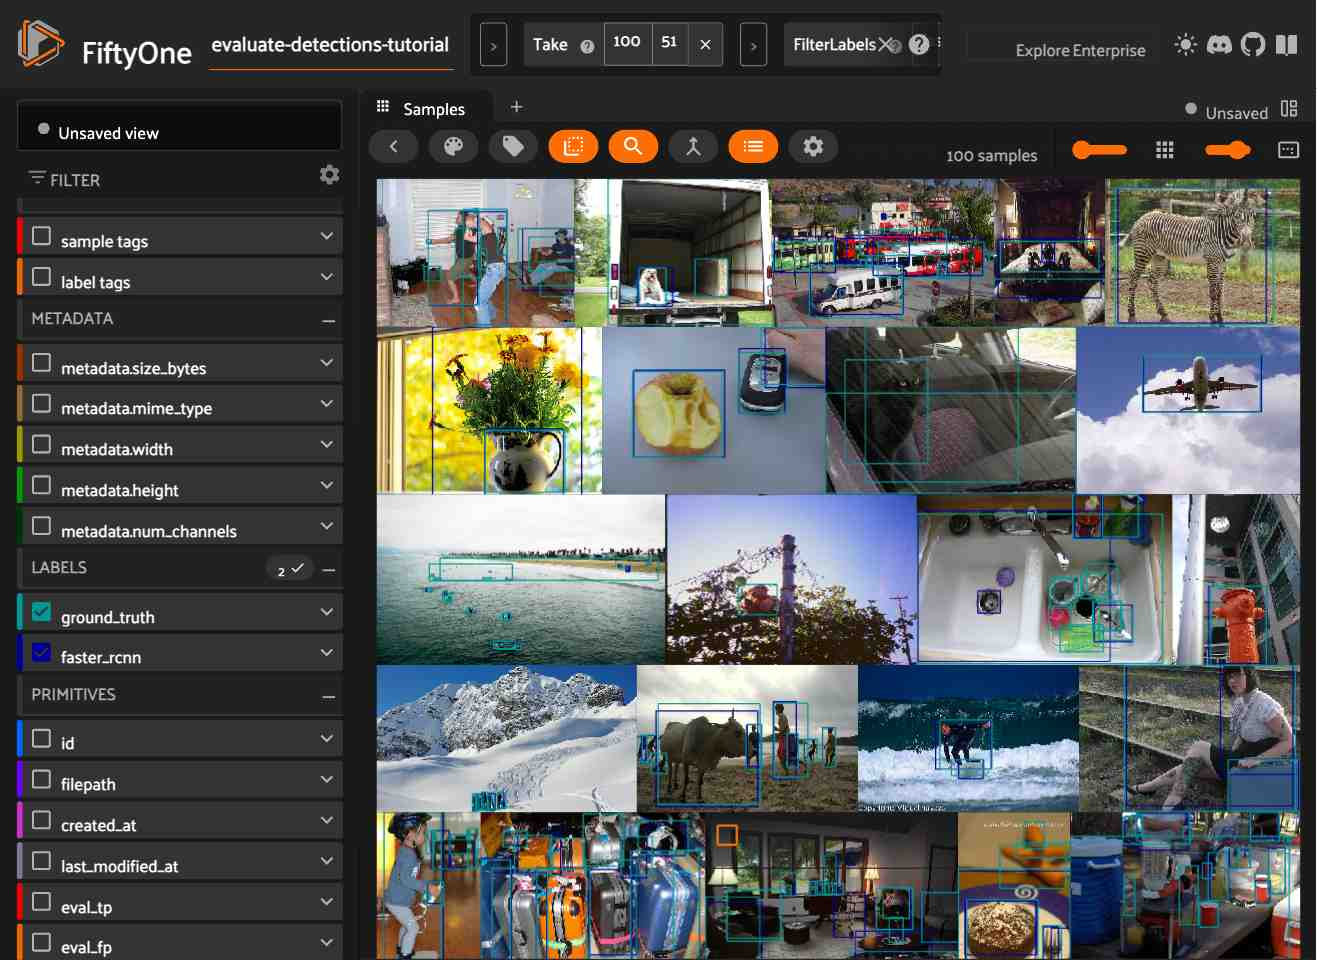

In [ ]:
session = fo.launch_app(high_conf_view)

### running evaluation

In [ ]:
results = high_conf_view.evaluate_detections(
    "faster_rcnn",
    gt_field="ground_truth",
    eval_key="eval",
    compute_mAP=True,
)

Evaluating detections...
 100% |█████████████████| 100/100 [889.4ms elapsed, 0s remaining, 112.4 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 100/100 [567.9ms elapsed, 0s remaining, 176.1 samples/s]      


In [ ]:
## evaluation 정보 저장
print(dataset.list_evaluations())
print(dataset.get_evaluation_info("eval"))

['eval']
{
    "key": "eval",
    "version": "1.4.1",
    "timestamp": "2025-06-13T05:20:39.974000",
    "config": {
        "cls": "fiftyone.utils.eval.coco.COCOEvaluationConfig",
        "type": "detection",
        "method": "coco",
        "pred_field": "faster_rcnn",
        "gt_field": "ground_truth",
        "iou": 0.5,
        "classwise": true,
        "custom_metrics": null,
        "iscrowd": "iscrowd",
        "use_masks": false,
        "use_boxes": false,
        "tolerance": null,
        "compute_mAP": true,
        "iou_threshs": [
            0.5,
            0.55,
            0.6,
            0.65,
            0.7,
            0.75,
            0.8,
            0.85,
            0.9,
            0.95
        ],
        "max_preds": 100,
        "error_level": 1
    }
}


In [ ]:
counts = dataset.count_values("ground_truth.detections.label")
classes_top10 = sorted(counts, key=counts.get, reverse=True)[:10]
results.print_report(classes=classes_top10)

               precision    recall  f1-score   support

       person       0.79      0.71      0.75       200
          car       0.38      1.00      0.56         5
        chair       0.69      0.35      0.46        52
         book       1.00      0.62      0.77        37
       bottle       0.67      0.57      0.62        21
          cup       0.68      0.36      0.47        42
 dining table       0.60      0.38      0.46        32
traffic light       0.00      0.00      0.00         3
         bowl       0.70      0.33      0.45        21
      handbag       0.67      0.29      0.40        14

    micro avg       0.74      0.56      0.64       427
    macro avg       0.62      0.46      0.49       427
 weighted avg       0.75      0.56      0.63       427



In [ ]:
print(results.mAP())

0.33627348169478777


In [5]:
%matplotlib inline

dataset = fo.load_dataset('evaluate-detections-tutorial')
results = dataset.load_evaluation_results("eval")

plot = results.plot_pr_curves(classes=["person", "car"])
plot.show()

FigureWidget({
    'data': [{'customdata': array([0.99987364, 0.99981241, 0.99972826, 0.99930462, 0.99903469, 0.89948943,
                                   0.89941443, 0.89928656, 0.89909443, 0.89883709, 0.8986947 , 0.89850962,
                                   0.89830766, 0.89776098, 0.89739318, 0.89621125, 0.89522492, 0.89440272,
                                   0.88680115, 0.7969754 , 0.79687452, 0.79648847, 0.79611381, 0.79595584,
                                   0.79497226, 0.79392034, 0.79336013, 0.79263581, 0.79159089, 0.79063514,
                                   0.78857272, 0.78754278, 0.78579215, 0.78296109, 0.78042612, 0.77596467,
                                   0.76284989, 0.6847    , 0.6836503 , 0.68211486, 0.68114071, 0.68005065,
                                   0.67763135, 0.67359098, 0.67117147, 0.67074299, 0.66544281, 0.65573229,
                                   0.57527754, 0.57206642, 0.56826   , 0.56571112, 0.56168551, 0.55347788,
                      

In [ ]:
sample = high_conf_view.first()
print(sample.faster_rcnn.detections[0])

<Detection: {
    'id': '684bb3929e8cc54221695119',
    'attributes': {},
    'tags': [],
    'label': 'person',
    'bounding_box': [
        0.2594649658203125,
        0.21519525146484375,
        0.2492353515625,
        0.6340693359375,
    ],
    'mask': None,
    'mask_path': None,
    'confidence': 0.9992185831069946,
    'index': None,
    'eval_iou': 0.9657918058774212,
    'eval_id': '684bb1ab9e8cc542216932bd',
    'eval': 'tp',
}>


In [ ]:
import fiftyone as fo
import fiftyone.zoo as foz
from fiftyone import ViewField as F

from ultralytics import YOLO

import numpy as np
import os
from tqdm import tqdm

### run inference (quickstart)

Dataset already downloaded
Loading existing dataset 'quickstart'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


100%|██████████| 6.25M/6.25M [00:00<00:00, 11.6MB/s]


 100% |█████████████████| 200/200 [13.2s elapsed, 0s remaining, 15.6 samples/s]      



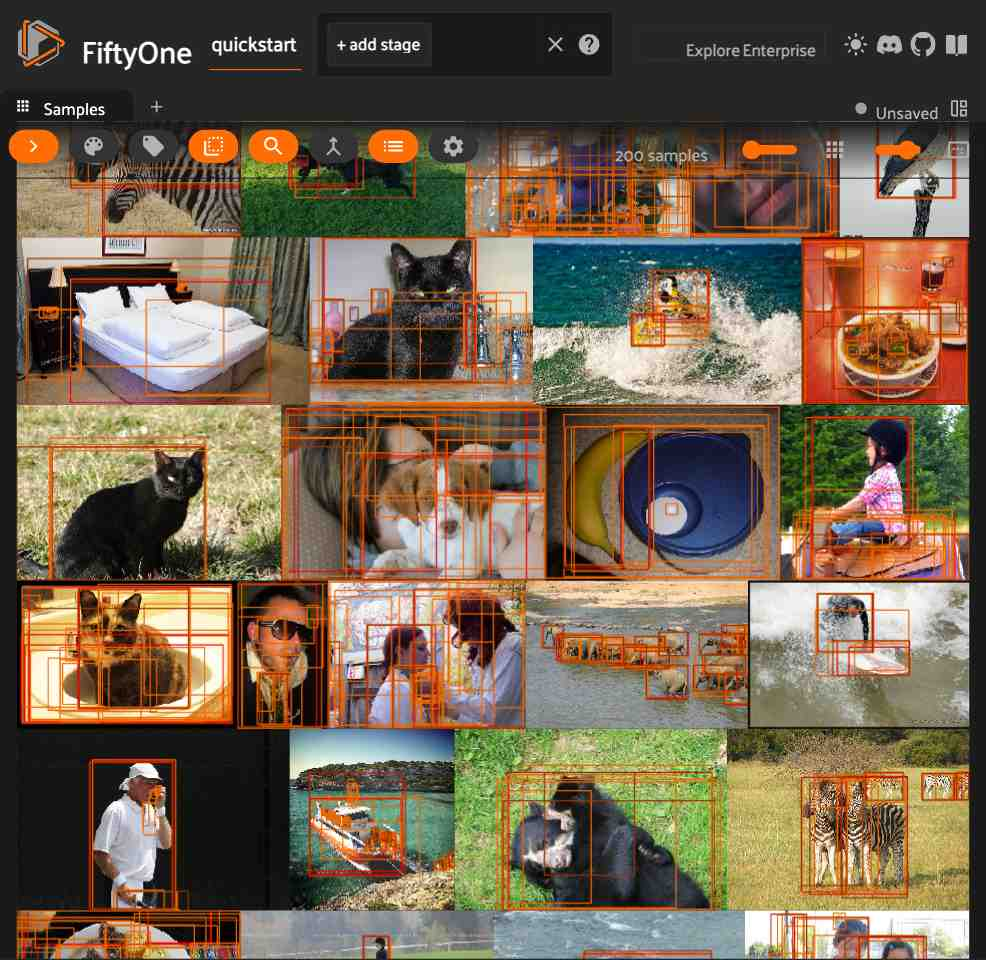

In [ ]:
dataset = foz.load_zoo_dataset("quickstart")
model = YOLO("yolov8n.pt")

dataset.apply_model(model, label_field="yolov8n")

session = fo.launch_app(dataset)

In [ ]:
fo.list_datasets()

['2025.06.19.17.22.46',
 '2025.06.19.17.57.43',
 'coco-2017-test',
 'demo0424',
 'evaluate-detections-tutorial',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'mnist-test',
 'quickstart',
 'quickstart-geo',
 'quickstart-video',
 'test_raw_imgs']

### run inference (coco2017-valid)

In [ ]:
dataset = foz.load_zoo_dataset("coco-2017", split="validation")

Found annotations at '/Users/bhc/fiftyone/coco-2017/raw/instances_val2017.json'
Images already downloaded
Existing download of split 'validation' is sufficient
Loading 'coco-2017' split 'validation'
 100% |███████████████| 5000/5000 [10.2s elapsed, 0s remaining, 519.3 samples/s]      
Dataset 'coco-2017-validation' created


In [ ]:
model = YOLO("yolov8n.pt")
dataset.apply_model(model, label_field="yolov8n")

 100% |███████████████| 5000/5000 [4.9m elapsed, 0s remaining, 18.8 samples/s]      



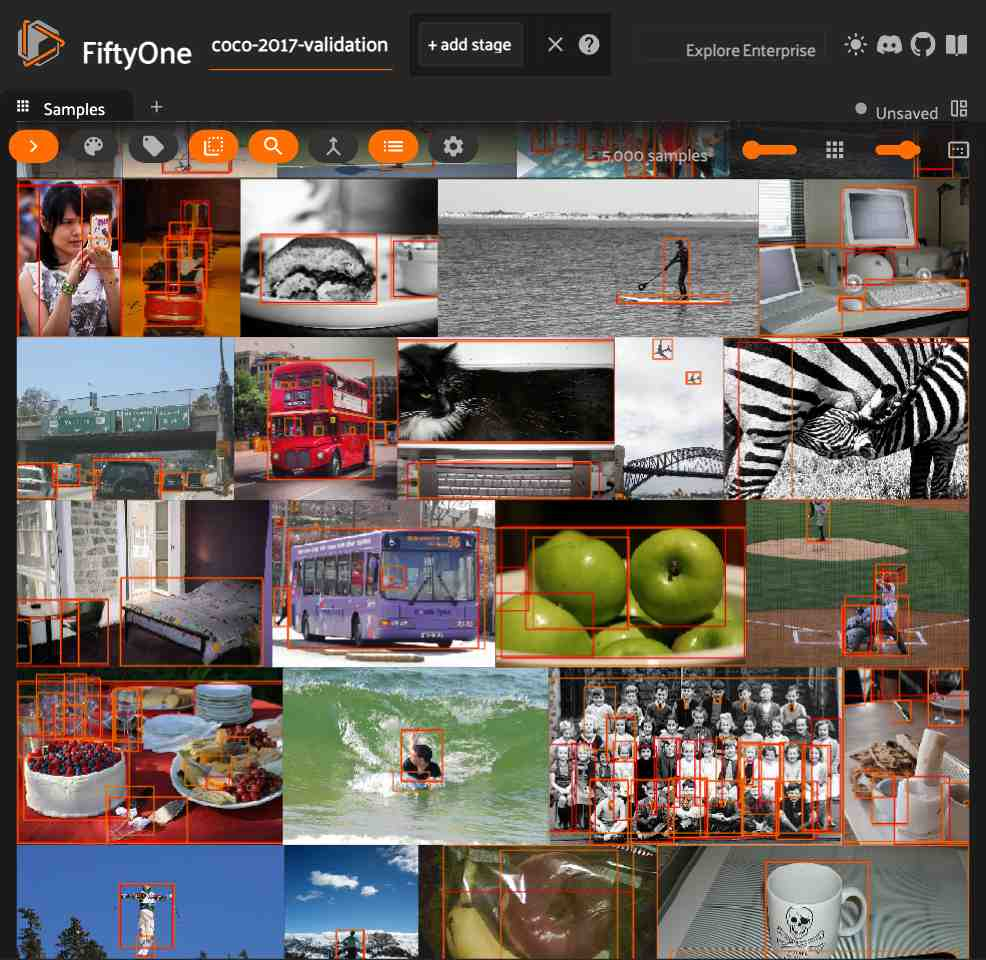

In [ ]:
session = fo.launch_app(dataset)

### data curations

test sets

In [ ]:
test_dataset = dataset.filter_labels(
    "ground_truth",
    F("label") == "bird"
).filter_labels(
    "yolov8n",
    F("label") == "bird",
    only_matches=False
).clone()

test_dataset.name = "birds-test-dataset"
test_dataset.persistent = True


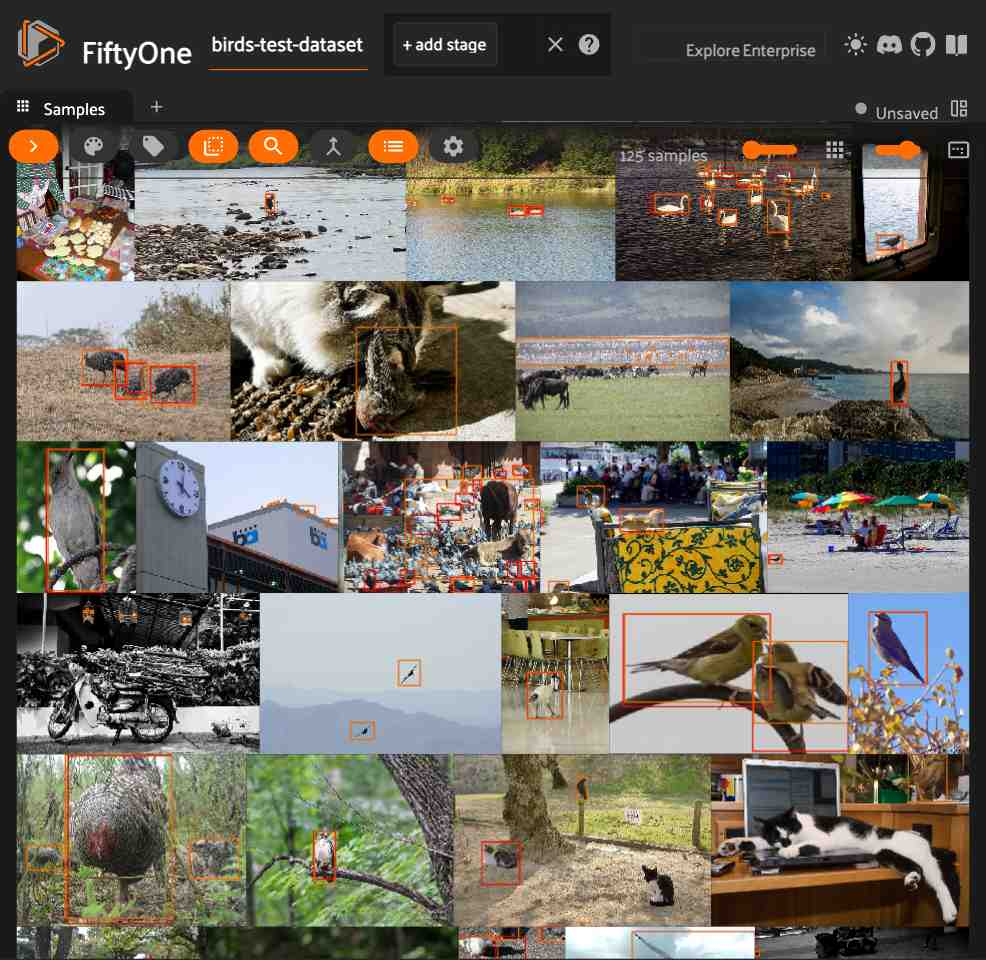

In [ ]:
session = fo.launch_app(test_dataset)

train sets (augmentation)

In [ ]:
## set classes to just include birds
classes = ["bird"]

In [ ]:
train_dataset = foz.load_zoo_dataset(
    'coco-2017',
    split='train',
    classes=classes
).clone()

train_dataset.name = "birds-train-data"
train_dataset.persistent = True
train_dataset.save()

Found annotations at '/Users/bhc/fiftyone/coco-2017/raw/instances_train2017.json'
 100% |████████████████| 3237/3237 [6.0m elapsed, 0s remaining, 8.9 images/s]       
Writing annotations for 3237 downloaded samples to '/Users/bhc/fiftyone/coco-2017/train/labels.json'
Dataset info written to '/Users/bhc/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'train'
 100% |███████████████| 3237/3237 [6.0s elapsed, 0s remaining, 553.9 samples/s]      
Dataset 'coco-2017-train' created


In [ ]:
oi_samples = foz.load_zoo_dataset(
    "open-images-v6",
    classes = ["Bird"],
    only_matching=True,
    label_types="detections"
).map_labels(
    "ground_truth",
    {"Bird":"bird"}
)

 100% |██████|    4.8Gb/4.8Gb [26.5s elapsed, 0s remaining, 176.8Mb/s]      
 100% |███████████████| 18525/18525 [16.9m elapsed, 0s remaining, 11.3 files/s]      
 100% |█████████████████| 1871/1871 [1.6m elapsed, 0s remaining, 20.7 files/s]      
 100% |███████████████████| 593/593 [39.0s elapsed, 0s remaining, 19.7 files/s]      
Dataset info written to '/Users/bhc/fiftyone/open-images-v6/info.json'
Loading 'open-images-v6' split 'train'
 100% |█████████████| 18525/18525 [21.9s elapsed, 0s remaining, 900.2 samples/s]      
Loading 'open-images-v6' split 'test'
 100% |███████████████| 1871/1871 [1.5s elapsed, 0s remaining, 1.2K samples/s]         
Loading 'open-images-v6' split 'validation'
 100% |█████████████████| 593/593 [420.9ms elapsed, 0s remaining, 1.4K samples/s]      
Dataset 'open-images-v6' created


In [ ]:
train_dataset.merge_samples(oi_samples)

In [ ]:
session = fo.launch_app(train_dataset)